In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from classy import CosmoComputationError

In [2]:
# ============================================================
# USER SWITCHES
# ============================================================

flag_save_plot = False
output_plot_name = "Bringmann2018_Fig7_like_thetaS_matching_safe.pdf"

z_rec = 1100.0
z_plot = 0.0

# k-range for P(k)
k_vals = np.logspace(-3, 0, 300)   # [h/Mpc]

# sigma8-dominant range from the paper-style plot
k_low_sigma8 = 0.025
k_high_sigma8 = 0.5

## SETUP: LCDM and LCDM + Monopoles

In [3]:
theta_s_100 = 1.04077
omega_b     = 0.02225
omega_c0    = 0.1198
tau_reio    = 0.0790
A_s         = np.exp(3.044) * 1e-10
n_s         = 0.9645

base_params = {
    "100*theta_s": theta_s_100,
    "omega_b": omega_b,
    "omega_cdm": omega_c0,
    "A_s": A_s,
    "n_s": n_s,
    "tau_reio": tau_reio,

    "output": "tCl,mPk,lCl",
    "non_linear": "none",
    "lensing": "yes",

    "P_k_max_h/Mpc": 1.5,
    "z_pk": "0.0",
}

In [4]:
# ============================================================
# BENCHMARKS
# ============================================================

# (a_t_mon, f_mon)
cases = [
    (5e-2, 0.2),
    (5e-4, 0.1),
    # (5e-6, 2.5),
]

kappa_list = [0.5]

## Helpers

In [5]:
def run_classy(params):
    """
    Run CLASS and return (cosmo, bg).
    """
    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()
    bg = cosmo.get_background()
    return cosmo, bg


def cleanup_class(cosmo):
    """
    Safely free CLASS memory.
    """
    if cosmo is None:
        return

    try:
        cosmo.struct_cleanup()
    except Exception:
        pass

    try:
        cosmo.empty()
    except Exception:
        pass


def get_bg_at_z(bg, z_target=1100.0):
    """
    Interpolate selected background quantities at target redshift.
    """
    z = np.asarray(bg["z"])
    order = np.argsort(z)
    z_sorted = z[order]

    def interp(key):
        if key not in bg:
            return None
        y = np.asarray(bg[key])[order]
        return np.interp(z_target, z_sorted, y)

    out = {
        "rho_cdm": interp("(.)rho_cdm"),
        "rho_mon": interp("(.)rho_mon"),
        "rho_dr": interp("(.)rho_dr"),
    }

    if "H [1/Mpc]" in bg:
        out["H"] = interp("H [1/Mpc]")

    return out


def compute_Pk_lin_hMpc(cosmo, k_hMpc, z):
    """
    classy.pk_lin(k,z) expects:
      k in 1/Mpc
    and returns:
      P in Mpc^3

    We convert to:
      input  k [h/Mpc]
      output P [(Mpc/h)^3]
    """
    h = cosmo.h()
    k_1Mpc = np.asarray(k_hMpc) * h
    P_Mpc3 = np.array([cosmo.pk_lin(float(k), float(z)) for k in k_1Mpc])
    P_Mpch3 = P_Mpc3 * h**3
    return P_Mpch3


def params_monopoles(f_mon, kappa_mon, a_t_mon):
    """
    New monopole implementation.
    """
    p = dict(base_params)
    p["f_mon"] = float(f_mon)
    p["kappa_mon"] = float(kappa_mon)
    p["a_t_mon"] = float(a_t_mon)

    # Uncomment if your parser still needs an explicit switch:
    # p["monopole_decay"] = "yes"

    return p

## Matching: CDM(z=1100) fixed

In [6]:
# ============================================================
# SAFE EVALUATION FOR MATCHING
# ============================================================

def safe_total_dm_at_zrec_for_guess(
    omega_cdm_guess,
    f_mon,
    kappa_mon,
    a_t_mon,
    z_rec,
    base_params
):
    """
    Return rho_cdm(z_rec) + rho_mon(z_rec) for a trial omega_cdm.
    If CLASS fails, return np.nan.
    """
    pars = dict(base_params)
    pars["omega_cdm"] = float(omega_cdm_guess)
    pars["f_mon"] = float(f_mon)
    pars["kappa_mon"] = float(kappa_mon)
    pars["a_t_mon"] = float(a_t_mon)

    cosmo_tmp = None
    try:
        cosmo_tmp, bg_tmp = run_classy(pars)
        bg_rec = get_bg_at_z(bg_tmp, z_rec)

        rho_c = bg_rec["rho_cdm"] if bg_rec["rho_cdm"] is not None else 0.0
        rho_d = bg_rec["rho_mon"] if bg_rec["rho_mon"] is not None else 0.0

        return rho_c + rho_d

    except CosmoComputationError:
        return np.nan
    except Exception:
        return np.nan
    finally:
        cleanup_class(cosmo_tmp)


def find_valid_bracket_for_matching(
    f_mon,
    kappa_mon,
    a_t_mon,
    rho_target,
    z_rec,
    base_params,
    omega_min=0.01,
    omega_max=1.5,
    n_grid=80,
    verbose=True
):
    """
    Scan omega_cdm values, keep only successful CLASS evaluations,
    and find adjacent valid points with opposite signs.
    """
    omega_grid = np.geomspace(omega_min, omega_max, n_grid)
    valid_points = []

    for omega in omega_grid:
        rho_val = safe_total_dm_at_zrec_for_guess(
            omega_cdm_guess=omega,
            f_mon=f_mon,
            kappa_mon=kappa_mon,
            a_t_mon=a_t_mon,
            z_rec=z_rec,
            base_params=base_params
        )

        if np.isfinite(rho_val):
            valid_points.append((omega, rho_val - rho_target))

    if verbose:
        print(
            f"[scan] a_t={a_t_mon:.0e}, f={f_mon}, kappa={kappa_mon}: "
            f"{len(valid_points)}/{len(omega_grid)} valid CLASS points"
        )

    if len(valid_points) < 2:
        raise RuntimeError(
            f"Too few valid CLASS points for bracket search: "
            f"(a_t={a_t_mon}, f={f_mon}, kappa={kappa_mon})."
        )

    for (omega1, f1), (omega2, f2) in zip(valid_points[:-1], valid_points[1:]):
        if f1 == 0.0:
            return omega1, omega1
        if f1 * f2 < 0:
            return omega1, omega2

    omega_vals = np.array([x[0] for x in valid_points])
    f_vals = np.array([x[1] for x in valid_points])

    raise RuntimeError(
        f"No sign change found in valid CLASS region for "
        f"(a_t={a_t_mon}, f={f_mon}, kappa={kappa_mon}).\n"
        f"Valid omega range: [{omega_vals.min():.4g}, {omega_vals.max():.4g}]\n"
        f"f(min omega)={f_vals[0]:.4e}, f(max omega)={f_vals[-1]:.4e}"
    )


def solve_omega_cdm_match_zrec(
    f_mon,
    kappa_mon,
    a_t_mon,
    rho_target,
    z_rec,
    base_params,
    tol=1e-8,
    maxit=60,
    verbose=True
):
    """
    Robust solve for omega_cdm(today) such that
    rho_cdm(z_rec) + rho_mon(z_rec) = rho_target.
    """
    lo, hi = find_valid_bracket_for_matching(
        f_mon=f_mon,
        kappa_mon=kappa_mon,
        a_t_mon=a_t_mon,
        rho_target=rho_target,
        z_rec=z_rec,
        base_params=base_params,
        verbose=verbose
    )

    if lo == hi:
        return lo

    def f_of_omega(omega):
        rho_val = safe_total_dm_at_zrec_for_guess(
            omega_cdm_guess=omega,
            f_mon=f_mon,
            kappa_mon=kappa_mon,
            a_t_mon=a_t_mon,
            z_rec=z_rec,
            base_params=base_params
        )

        if not np.isfinite(rho_val):
            return np.nan
        return rho_val - rho_target

    f_lo = f_of_omega(lo)
    f_hi = f_of_omega(hi)

    if not np.isfinite(f_lo) or not np.isfinite(f_hi):
        raise RuntimeError(
            f"Bracket endpoints invalid for "
            f"(a_t={a_t_mon}, f={f_mon}, kappa={kappa_mon})."
        )

    for _ in range(maxit):
        mid = 0.5 * (lo + hi)
        f_mid = f_of_omega(mid)

        # If midpoint is invalid, try nearby sub-midpoints
        if not np.isfinite(f_mid):
            mid_left = 0.5 * (lo + mid)
            mid_right = 0.5 * (mid + hi)

            f_left = f_of_omega(mid_left)
            f_right = f_of_omega(mid_right)

            if np.isfinite(f_left):
                mid, f_mid = mid_left, f_left
            elif np.isfinite(f_right):
                mid, f_mid = mid_right, f_right
            else:
                raise RuntimeError(
                    f"All midpoint probes invalid for "
                    f"(a_t={a_t_mon}, f={f_mon}, kappa={kappa_mon})."
                )

        if abs(f_mid) < tol:
            return mid

        if f_lo * f_mid <= 0:
            hi, f_hi = mid, f_mid
        else:
            lo, f_lo = mid, f_mid

    return 0.5 * (lo + hi)

In [7]:
# ============================================================
# REFERENCE LCDM RUN
# ============================================================

cosmo_ref = None
cosmo_ref, bg_ref = run_classy(base_params)
bg_rec_ref = get_bg_at_z(bg_ref, z_rec)

rhoDM_ref_1100 = bg_rec_ref["rho_cdm"]

print("=" * 80)
print("Reference LCDM")
print(f"100*theta_s        = {theta_s_100}")
print(f"derived h          = {cosmo_ref.h():.6f}")
print(f"rho_cdm(z={z_rec:.0f}) = {rhoDM_ref_1100:.8e}")
print("=" * 80)

P_ref = compute_Pk_lin_hMpc(cosmo_ref, k_vals, z_plot)


Reference LCDM
100*theta_s        = 1.04077
derived h          = 0.674566
rho_cdm(z=1100) = 1.77900665e+01


In [8]:
# ============================================================
# MODEL RUNS
# ============================================================

models = []

for kappa_mon in kappa_list:
    for a_t_mon, f_mon in cases:
        print(f"I m start calculating: (kappa, a_t, f_mon): {kappa_mon, a_t_mon, f_mon}")

        omega_best = solve_omega_cdm_match_zrec(
            f_mon=f_mon,
            kappa_mon=kappa_mon,
            a_t_mon=a_t_mon,
            rho_target=rhoDM_ref_1100,
            z_rec=z_rec,
            base_params=base_params,
            verbose=True
        )

        pars = params_monopoles(
            f_mon=f_mon,
            kappa_mon=kappa_mon,
            a_t_mon=a_t_mon
        )
        pars["omega_cdm"] = float(omega_best)

        cosmo_m = None
        try:
            cosmo_m, bg_m = run_classy(pars)
            bg_rec_m = get_bg_at_z(bg_m, z_rec)

            rho_c = bg_rec_m["rho_cdm"] if bg_rec_m["rho_cdm"] is not None else 0.0
            rho_d = bg_rec_m["rho_mon"] if bg_rec_m["rho_mon"] is not None else 0.0
            rho_tot = rho_c + rho_d

            P_m = compute_Pk_lin_hMpc(cosmo_m, k_vals, z_plot)

            match_err = (rho_tot - rhoDM_ref_1100) / rhoDM_ref_1100

            print(
                f"kappa={kappa_mon:>3}, a_t={a_t_mon:.0e}, f={f_mon:>4}: "
                f"omega_cdm(today)={omega_best:.6f}, "
                f"h={cosmo_m.h():.6f}, "
                f"rho_tot(z_rec)={rho_tot:.8e}, "
                f"match_err={match_err:.3e}"
            )

            models.append({
                "kappa_mon": kappa_mon,
                "a_t_mon": a_t_mon,
                "f_mon": f_mon,
                "omega_cdm": omega_best,
                "h": cosmo_m.h(),
                "rho_tot_zrec": rho_tot,
                "match_err": match_err,
                "P": P_m,
            })

        finally:
            cleanup_class(cosmo_m)

cleanup_class(cosmo_ref)

I m start calculating: (kappa, a_t, f_mon): (0.5, 0.05, 0.2)
[scan] a_t=5e-02, f=0.2, kappa=0.5: 67/80 valid CLASS points
kappa=0.5, a_t=5e-02, f= 0.2: omega_cdm(today)=0.102311, h=0.774196, rho_tot(z_rec)=1.77900665e+01, match_err=3.453e-10
I m start calculating: (kappa, a_t, f_mon): (0.5, 0.0005, 0.1)
[scan] a_t=5e-04, f=0.1, kappa=0.5: 65/80 valid CLASS points
kappa=0.5, a_t=5e-04, f= 0.1: omega_cdm(today)=0.115047, h=0.724040, rho_tot(z_rec)=1.77900665e+01, match_err=-4.436e-10


## Plot

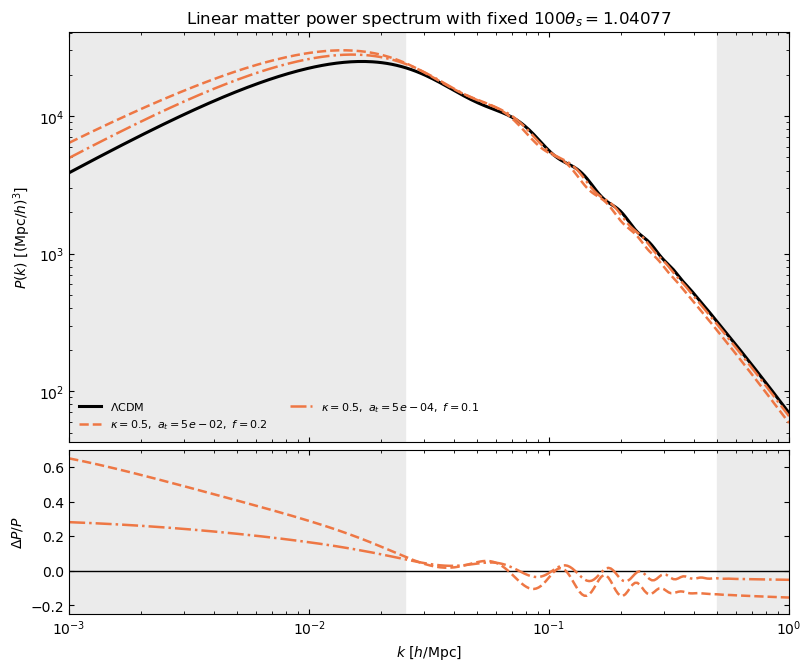

In [9]:
# ============================================================
# PLOT
# ============================================================

style_map = {
    (2.0, 5e-2, 0.2): dict(color="#88aa44", ls="--", lw=1.8),
    (2.0, 5e-4, 0.1): dict(color="#88aa44", ls="-.", lw=1.8),
    (2.0, 5e-6, 2.5): dict(color="#88aa44", ls="-", lw=1.8),

    (0.5, 5e-2, 0.2): dict(color="#ee7744", ls="--", lw=1.8),
    (0.5, 5e-4, 0.1): dict(color="#ee7744", ls="-.", lw=1.8),
    (0.5, 5e-6, 2.5): dict(color="#ee7744", ls="-", lw=1.8),
}

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8.0, 6.6),
    sharex=True,
    gridspec_kw={"height_ratios": [3.0, 1.2]},
    constrained_layout=True
)

for ax in (ax1, ax2):
    ax.axvspan(k_vals.min(), k_low_sigma8, color="0.92", zorder=0)
    ax.axvspan(k_high_sigma8, k_vals.max(), color="0.92", zorder=0)

# Top panel
ax1.plot(k_vals, P_ref, color="black", lw=2.2, label=r"$\Lambda$CDM")

for model in models:
    key = (model["kappa_mon"], model["a_t_mon"], model["f_mon"])
    plot_style = style_map.get(key, dict(lw=1.8))

    ax1.plot(
        k_vals,
        model["P"],
        **plot_style,
        label=rf"$\kappa={model['kappa_mon']},\ a_t={model['a_t_mon']:.0e},\ f={model['f_mon']}$"
    )

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim(1e-3, 1.0)
ax1.set_ylabel(r"$P(k)\ \left[(\mathrm{Mpc}/h)^3\right]$")
ax1.set_title(rf"Linear matter power spectrum with fixed $100\theta_s={theta_s_100}$")
ax1.tick_params(which="both", direction="in", top=True, right=True)

# Bottom panel
ax2.axhline(0.0, color="black", lw=1.0)

eps = 1e-60
valid_ref = np.isfinite(P_ref) & (np.abs(P_ref) > eps)

for model in models:
    key = (model["kappa_mon"], model["a_t_mon"], model["f_mon"])
    plot_style = style_map.get(key, dict(lw=1.8))

    frac = np.full_like(P_ref, np.nan, dtype=float)
    mvalid = valid_ref & np.isfinite(model["P"])
    frac[mvalid] = (model["P"][mvalid] - P_ref[mvalid]) / P_ref[mvalid]

    ax2.plot(k_vals[mvalid], frac[mvalid], **plot_style)

ax2.set_xscale("log")
ax2.set_xlim(1e-3, 1.0)
ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$")
ax2.set_ylabel(r"$\Delta P/P$")
ax2.set_ylim(-0.25, 0.7)
ax2.tick_params(which="both", direction="in", top=True, right=True)

ax1.legend(frameon=False, fontsize=8, loc="lower left", ncol=2)

if flag_save_plot:
    fig.savefig(output_plot_name, bbox_inches="tight")
else:
    plt.show()